# Diabetes Classification

Phân loại bệnh tiểu đường bằng Machine Learning với **SVC** và **Random Forest**.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# from ydata_profiling import ProfileReport

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

## 1. Load Dataset

Đọc dataset `diabetes.csv` và kiểm tra dữ liệu ban đầu.

In [2]:
data = pd.read_csv("diabetes.csv")
data.head(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


## 2. Exploratory Data Analysis (EDA)

Kiểm tra thông tin, thống kê mô tả, kích thước và giá trị thiếu của dataset.

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               800 non-null    int64  
 1   Glucose                   800 non-null    int64  
 2   BloodPressure             800 non-null    int64  
 3   SkinThickness             800 non-null    int64  
 4   Insulin                   800 non-null    int64  
 5   BMI                       800 non-null    float64
 6   DiabetesPedigreeFunction  800 non-null    float64
 7   Age                       800 non-null    int64  
 8   Outcome                   800 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 56.4 KB


In [4]:
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000
mean,3.837500,121.105000,68.951250,20.298750,79.948750,32.031125,0.471105,33.280000,0.348750
std,3.363069,31.944828,19.415008,16.010854,116.268877,7.860584,0.330756,11.854631,0.476873
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.240750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,27.000000,32.150000,0.370500,29.000000,0.000000
75%,6.000000,141.000000,80.000000,32.000000,127.250000,36.625000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [5]:
data.shape

(800, 9)

In [6]:
data.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [7]:
'''
profile = ProfileReport(
    data,
    title="Diabetes Dataset Report",
    explorative=True
)

profile.to_file("diabetes_report.html")
'''

'\nprofile = ProfileReport(\n    data,\n    title="Diabetes Dataset Report",\n    explorative=True\n)\n\nprofile.to_file("diabetes_report.html")\n'

## 3. Define Features and Target

- **Features (X):** các biến đầu vào dùng để dự đoán.
- **Target (y):** `Outcome`, biến mục tiêu cần dự đoán.

In [8]:
target = "Outcome"
X = data.drop(target, axis=1)
y = data[target]
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (800, 8)
y shape: (800,)


## 4. Split Dataset

Chia dữ liệu thành **Train / Validation / Test**.

- Test: 20%
- Phần còn lại: 80%
- Validation: 25% của 80% = 20% toàn bộ dữ liệu
- Train: 60% toàn bộ dữ liệu

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=100)

In [10]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.25,
    random_state=100
)


In [11]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (480, 8)
y_train: (480,)
X_val: (160, 8)
y_val: (160,)
X_test: (160, 8)
y_test: (160,)


## 5. Data Preprocessing

Sử dụng `StandardScaler` để chuẩn hóa các feature.

> Chỉ `fit` trên tập training để tránh **data leakage**. Validation và Test chỉ dùng `transform`.

In [12]:
scaler = StandardScaler()

In [13]:
X_train = scaler.fit_transform(X_train)

In [14]:
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

## 6. Build Models

Xây dựng hai baseline models:

1. **SVC (Support Vector Classifier)**
2. **Random Forest Classifier**

In [15]:
# Pick models
svc_model = SVC()
rf_model = RandomForestClassifier(random_state=100)

## 7. Training

Huấn luyện các model bằng **training set**.

In [32]:
#svc_model.fit(X_train, y_train)

In [33]:
#rf_model.fit(X_train, y_train)

## 8. Validation Evaluation

Đánh giá model trên **validation set** trước khi đánh giá cuối cùng trên test set.

In [18]:
y_val_pred_svc = svc_model.predict(X_val)
y_val_pred_rf = rf_model.predict(X_val)

In [19]:
print("===== SVC - Validation =====")
print("Accuracy :", accuracy_score(y_val, y_val_pred_svc))
print("Precision:", precision_score(y_val, y_val_pred_svc))
print("Recall   :", recall_score(y_val, y_val_pred_svc))
print("F1 Score :", f1_score(y_val, y_val_pred_svc))

===== SVC - Validation =====
Accuracy : 0.8125
Precision: 0.8863636363636364
Recall   : 0.609375
F1 Score : 0.7222222222222222


In [20]:
print("===== Random Forest - Validation =====")
print("Accuracy :", accuracy_score(y_val, y_val_pred_rf))
print("Precision:", precision_score(y_val, y_val_pred_rf))
print("Recall   :", recall_score(y_val, y_val_pred_rf))
print("F1 Score :", f1_score(y_val, y_val_pred_rf))

===== Random Forest - Validation =====
Accuracy : 0.78125
Precision: 0.7959183673469388
Recall   : 0.609375
F1 Score : 0.6902654867256637


In [21]:
print("===== SVC - Validation =====")
print(classification_report(y_val, y_val_pred_svc))

===== SVC - Validation =====
              precision    recall  f1-score   support

           0       0.78      0.95      0.86        96
           1       0.89      0.61      0.72        64

    accuracy                           0.81       160
   macro avg       0.84      0.78      0.79       160
weighted avg       0.83      0.81      0.80       160



In [22]:
print("===== Random Forest - Validation =====")
print(classification_report(y_val, y_val_pred_rf))

===== Random Forest - Validation =====
              precision    recall  f1-score   support

           0       0.77      0.90      0.83        96
           1       0.80      0.61      0.69        64

    accuracy                           0.78       160
   macro avg       0.79      0.75      0.76       160
weighted avg       0.78      0.78      0.77       160



## 9. Test Evaluation

Đánh giá cuối cùng trên **test set** sau khi hoàn thành bước validation.

In [23]:
y_test_pred_svc = svc_model.predict(X_test)
y_test_pred_rf = rf_model.predict(X_test)

In [24]:
print("===== SVC - Test =====")
print("Accuracy :", accuracy_score(y_test, y_test_pred_svc))
print("Precision:", precision_score(y_test, y_test_pred_svc))
print("Recall   :", recall_score(y_test, y_test_pred_svc))
print("F1 Score :", f1_score(y_test, y_test_pred_svc))

===== SVC - Test =====
Accuracy : 0.70625
Precision: 0.5454545454545454
Recall   : 0.47058823529411764
F1 Score : 0.5052631578947369


In [25]:
print(classification_report(y_test, y_test_pred_svc))

              precision    recall  f1-score   support

           0       0.77      0.82      0.79       109
           1       0.55      0.47      0.51        51

    accuracy                           0.71       160
   macro avg       0.66      0.64      0.65       160
weighted avg       0.70      0.71      0.70       160



In [26]:
print("===== Random Forest - Test =====")
print("Accuracy :", accuracy_score(y_test, y_test_pred_rf))
print("Precision:", precision_score(y_test, y_test_pred_rf))
print("Recall   :", recall_score(y_test, y_test_pred_rf))
print("F1 Score :", f1_score(y_test, y_test_pred_rf))

===== Random Forest - Test =====
Accuracy : 0.76875
Precision: 0.6842105263157895
Recall   : 0.5098039215686274
F1 Score : 0.5842696629213483


## 10. Confusion Matrix — SVC

Ma trận nhầm lẫn của SVC trên test set.

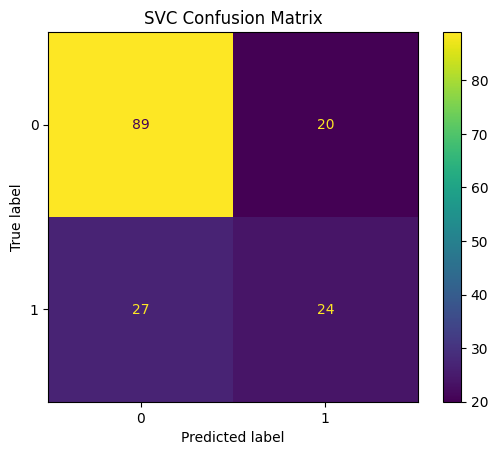

In [27]:
ConfusionMatrixDisplay.from_predictions(y_test,y_test_pred_svc)
plt.title("SVC Confusion Matrix")
plt.show()

In [28]:
cm_svc=confusion_matrix(y_test,y_test_pred_svc)
TN,FP,FN,TP=cm_svc.ravel()
print("TN-Số lượng người không bị bệnh và model đoán đúng là không bị bệnh =",TN)
print("FP-Số lượng người không mắc bệnh nhưng mô hình dự đoán có bệnh =",FP)
print("FN-Số lượng người mắc bệnh nhưng mô hình dự đoán không có bệnh =",FN)
print("TP-Số lượng người mắc bệnh và model đoán đúng là có bệnh =",TP)


TN-Số lượng người không bị bệnh và model đoán đúng là không bị bệnh = 89
FP-Số lượng người không mắc bệnh nhưng mô hình dự đoán có bệnh = 20
FN-Số lượng người mắc bệnh nhưng mô hình dự đoán không có bệnh = 27
TP-Số lượng người mắc bệnh và model đoán đúng là có bệnh = 24


## 11. Confusion Matrix — Random Forest

Ma trận nhầm lẫn của Random Forest trên test set.

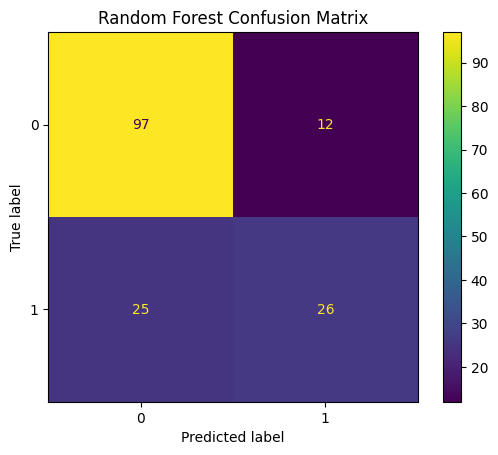

In [29]:
ConfusionMatrixDisplay.from_predictions(y_test,y_test_pred_rf)
plt.title("Random Forest Confusion Matrix")
plt.show()

In [30]:
cm_rf=confusion_matrix(y_test,y_test_pred_rf)
TN,FP,FN,TP=cm_rf.ravel()
print("TN-Số lượng người không bị bệnh và model đoán đúng là không bị bệnh =",TN)
print("FP-Số lượng người không mắc bệnh nhưng mô hình dự đoán có bệnh =",FP)
print("FN-Số lượng người mắc bệnh nhưng mô hình dự đoán không có bệnh =",FN)
print("TP-Số lượng người mắc bệnh và model đoán đúng là có bệnh =",TP)

TN-Số lượng người không bị bệnh và model đoán đúng là không bị bệnh = 97
FP-Số lượng người không mắc bệnh nhưng mô hình dự đoán có bệnh = 12
FN-Số lượng người mắc bệnh nhưng mô hình dự đoán không có bệnh = 25
TP-Số lượng người mắc bệnh và model đoán đúng là có bệnh = 26


## 12. Model Comparison

So sánh Accuracy, Precision, Recall và F1 Score của hai model.

In [31]:
results = pd.DataFrame({
    "Model": ["SVC", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_test_pred_svc),
        accuracy_score(y_test, y_test_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_test_pred_svc),
        precision_score(y_test, y_test_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_test_pred_svc),
        recall_score(y_test, y_test_pred_rf)
    ],
    "F1": [
        f1_score(y_test, y_test_pred_svc),
        f1_score(y_test, y_test_pred_rf)
    ]
})
results

,Model,Accuracy,Precision,Recall,F1
0,SVC,0.70625,0.545455,0.470588,0.505263
1,Random Forest,0.76875,0.684211,0.509804,0.584270
